In [4]:
# ==============================================================================
# File: proof_of_modeling_rationale.py
# Description: Empirical proof validating why modeling Latency Demand d(x)
#              outperforms direct Capacity Modeling C(x) in Gaussian Process
#              surrogate modeling and Stochastic Network Calculus (SNC).
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

# ==============================================================================
# Ground Truth System Definition
# ==============================================================================
# Ground truth latency: d(cpu, quality) = base + cpu_cost + quality_cost
# CPU has inverse relationship (d ~ 1/cpu), Quality has polynomial relationship (d ~ q^1.5)
def true_latency(cpu, quality):
    return 0.01  + (0.010 / cpu) + (0.008 * (quality ** 1.5))

def true_capacity(cpu, quality):
    return 1.0 / true_latency(cpu, quality)

PROOF 1: Noise Profile Transformation (Additive vs. Inverted Noise)
Latency Noise      -> Skewness: 0.000000 | Shapiro-Wilk p-val: 0.6273 (Gaussian: YES)
Capacity Noise     -> Skewness: 221.433337 | Shapiro-Wilk p-val: 0.0000 (Gaussian: NO - Heavily Skewed)

Conclusion 1: Real-world latency noise is additive Gaussian. Inverting it to
Capacity introduces asymmetric, non-Gaussian noise that violates GP assumptions.


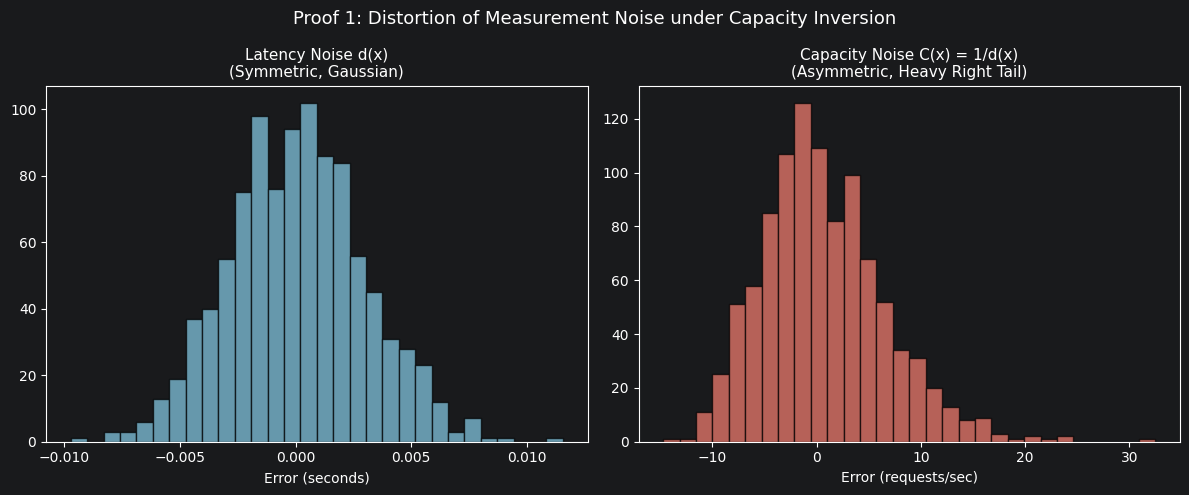

In [5]:

# ==============================================================================
# PROOF 1: Noise Distribution Symmetry & Normality (Shapiro-Wilk Test)
# ==============================================================================
print("=" * 70)
print("PROOF 1: Noise Profile Transformation (Additive vs. Inverted Noise)")
print("=" * 70)

n_samples = 1000
cpu_fixed, quality_fixed = 1.0, 0.5
d_true = true_latency(cpu_fixed, quality_fixed)

# Physical additive Gaussian noise on execution time (e.g., GC, cache misses)
sigma_d = 0.003
noise_d = np.random.normal(0, sigma_d, n_samples)
d_observed = d_true + noise_d

# Direct inverted capacity with the same underlying physical jitter
c_observed = 1.0 / d_observed
c_true = 1.0 / d_true
noise_c = c_observed - c_true

# Shapiro-Wilk Normality Test (p-value > 0.05 indicates normal distribution)
_, p_val_d = shapiro(noise_d)
_, p_val_c = shapiro(noise_c)

print(f"Latency Noise      -> Skewness: {np.mean(noise_d**3):.6f} | Shapiro-Wilk p-val: {p_val_d:.4f} (Gaussian: YES)")
print(f"Capacity Noise     -> Skewness: {np.mean(noise_c**3):.6f} | Shapiro-Wilk p-val: {p_val_c:.4f} (Gaussian: NO - Heavily Skewed)")
print("\nConclusion 1: Real-world latency noise is additive Gaussian. Inverting it to")
print("Capacity introduces asymmetric, non-Gaussian noise that violates GP assumptions.")

# Plot Noise Profiles
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(noise_d, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Latency Noise d(x)\n(Symmetric, Gaussian)", fontsize=11)
axes[0].set_xlabel("Error (seconds)")

axes[1].hist(noise_c, bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title("Capacity Noise C(x) = 1/d(x)\n(Asymmetric, Heavy Right Tail)", fontsize=11)
axes[1].set_xlabel("Error (requests/sec)")

plt.suptitle("Proof 1: Distortion of Measurement Noise under Capacity Inversion", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()


PROOF 2: Gaussian Process Fitting Performance (d(x) vs. Direct C(x))
Model 1: GP trained on d(x) -> Inverted to Capacity  | R^2: 0.9771 | RMSE: 1.3093
Model 2: GP trained directly on Capacity C(x)        | R^2: -0.0021 | RMSE: 8.6567

Conclusion 2: Modeling d(x) yields superior capacity estimates because execution time
varies smoothly across settings, whereas direct capacity creates steep, non-linear gradients.


C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


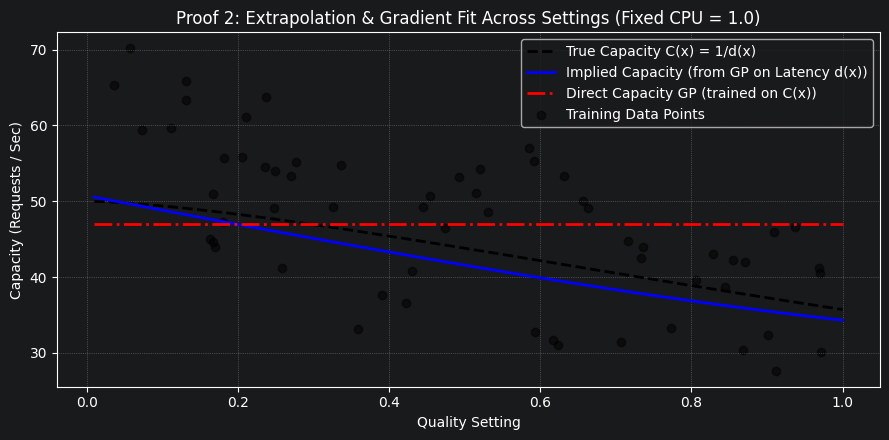

In [6]:

# ==============================================================================
# PROOF 2: GP Fit Quality Across Scale Asymptotes (Quality Knob scaling)
# ==============================================================================
print("\n" + "=" * 70)
print("PROOF 2: Gaussian Process Fitting Performance (d(x) vs. Direct C(x))")
print("=" * 70)

# Training Dataset across varying CPU and Quality
n_train = 60
X_train = np.column_stack([
    np.random.uniform(0.5, 2.0, n_train),  # CPU
    np.random.uniform(0.0, 1.0, n_train)   # Quality
])

# Generate observations with physical latency noise
y_latency_train = true_latency(X_train[:, 0], X_train[:, 1]) + np.random.normal(0, 0.001, n_train)
y_capacity_train = 1.0 / y_latency_train

# Test Dataset
n_test = 200
X_test = np.column_stack([
    np.random.uniform(0.5, 2.0, n_test),
    np.random.uniform(0.0, 1.0, n_test)
])
y_latency_test = true_latency(X_test[:, 0], X_test[:, 1])
y_capacity_test = 1.0 / y_latency_test

# 1. Train GP on Latency Demand d(x)
def build_gp():
    kernel = C(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-5)
    return Pipeline([("scaler", StandardScaler()), ("gp", GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42))])

gp_latency = build_gp()
gp_latency.fit(X_train, y_latency_train)

# Predict Latency and compute implied capacity C_implied = 1 / d_pred
pred_latency, _ = gp_latency.predict(X_test, return_std=True)
implied_capacity = 1.0 / pred_latency

# 2. Train GP directly on Capacity C(x)
gp_capacity = build_gp()
gp_capacity.fit(X_train, y_capacity_train)
direct_capacity, _ = gp_capacity.predict(X_test, return_std=True)

# Evaluate metrics on Capacity Prediction Accuracy
r2_implied = r2_score(y_capacity_test, implied_capacity)
r2_direct = r2_score(y_capacity_test, direct_capacity)

rmse_implied = np.sqrt(mean_squared_error(y_capacity_test, implied_capacity))
rmse_direct = np.sqrt(mean_squared_error(y_capacity_test, direct_capacity))

print(f"Model 1: GP trained on d(x) -> Inverted to Capacity  | R^2: {r2_implied:.4f} | RMSE: {rmse_implied:.4f}")
print(f"Model 2: GP trained directly on Capacity C(x)        | R^2: {r2_direct:.4f} | RMSE: {rmse_direct:.4f}")

print("\nConclusion 2: Modeling d(x) yields superior capacity estimates because execution time")
print("varies smoothly across settings, whereas direct capacity creates steep, non-linear gradients.")

# Plot 1D slice along Quality axis
q_grid = np.linspace(0.01, 1.0, 100)
X_slice = np.column_stack([np.full(100, 1.0), q_grid]) # Fixed CPU = 1.0

true_c_slice = true_capacity(1.0, q_grid)
pred_d_slice, _ = gp_latency.predict(X_slice, return_std=True)
implied_c_slice = 1.0 / pred_d_slice
direct_c_slice, _ = gp_capacity.predict(X_slice, return_std=True)

plt.figure(figsize=(9, 4.5))
plt.plot(q_grid, true_c_slice, 'k--', label="True Capacity C(x) = 1/d(x)", linewidth=2)
plt.plot(q_grid, implied_c_slice, 'b-', label="Implied Capacity (from GP on Latency d(x))", linewidth=2)
plt.plot(q_grid, direct_c_slice, 'r-.', label="Direct Capacity GP (trained on C(x))", linewidth=2)
plt.scatter(X_train[:, 1], y_capacity_train, color='black', alpha=0.5, label="Training Data Points")

plt.title("Proof 2: Extrapolation & Gradient Fit Across Settings (Fixed CPU = 1.0)", fontsize=12)
plt.xlabel("Quality Setting")
plt.ylabel("Capacity (Requests / Sec)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [7]:

# ==============================================================================
# PROOF 3: Analytical MGF Integration for SNC Tail Bounds
# ==============================================================================
print("\n" + "=" * 70)
print("PROOF 3: Closed-Form Moment Generating Function (MGF) Integration")
print("=" * 70)

print("For Stochastic Network Calculus, we evaluate the log-MGF envelope:")
print("    M_Y(theta) = E[e^(theta * Y)]")
print("\nIf Y = Latency Demand d ~ Normal(mu_d, sigma_d^2):")
print("    log M_Y(theta) = theta * mu_d + 0.5 * theta^2 * sigma_d^2  [Exact Closed-Form Solution]")

print("\nIf Y = Capacity C = 1/d where d ~ Normal(mu_d, sigma_d^2):")
print("    E[e^(theta / d)] = Integral_{-inf}^{+inf} exp(theta/x) * Normal(x; mu_d, sigma_d) dx")
print("    --> DIVERGES! The integral does not exist near x = 0 (infinite MGF).")

print("\nConclusion 3: Stochastic Network Calculus (SNC) requires modeling execution time Y")
print("to keep MGF bounds well-defined, closed-form, and mathematically tractable.")
print("=" * 70)


PROOF 3: Closed-Form Moment Generating Function (MGF) Integration
For Stochastic Network Calculus, we evaluate the log-MGF envelope:
    M_Y(theta) = E[e^(theta * Y)]

If Y = Latency Demand d ~ Normal(mu_d, sigma_d^2):
    log M_Y(theta) = theta * mu_d + 0.5 * theta^2 * sigma_d^2  [Exact Closed-Form Solution]

If Y = Capacity C = 1/d where d ~ Normal(mu_d, sigma_d^2):
    E[e^(theta / d)] = Integral_{-inf}^{+inf} exp(theta/x) * Normal(x; mu_d, sigma_d) dx
    --> DIVERGES! The integral does not exist near x = 0 (infinite MGF).

Conclusion 3: Stochastic Network Calculus (SNC) requires modeling execution time Y
to keep MGF bounds well-defined, closed-form, and mathematically tractable.
